<a href="https://colab.research.google.com/github/jlloring/ST-554_JLoring/blob/main/Loring_HW6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ST 554 Homework 6**
---
Authored by: Jamie Loring

In [ ]:
# importing required modules:
import pandas as pd
import numpy as np
from numpy.random import default_rng
import matplotlib.pyplot as plt
import sqlite3
from sklearn import linear_model

## **Part 1: More Practice Querying a Database**

This section uses the `lahman_1871-2022.sqlite` database that has information on Major League Baseball (MLB).

#### **Question 1**
*The text and code below for this question were directly copied from my HW5 notebook as this question is asking for the same exact thing.*

The code below connects to the database that is uploaded to Colab. This file must be re-uploaded to the *Files* section at the start of each new session!

In [ ]:
con = sqlite3.connect("lahman_1871-2022.sqlite")

Continuing on, the code below looks at all the tables in the database. In addition, the `read_sql()` function from `pandas` is used to have this result returned as a data frame.

In [ ]:
#SQL query to return all table names in the database
get_schema = '''
             select *
             from sqlite_schema
             where type = 'table';
             '''
#puts result of SQL query into pandas df -- don't need a cursor object!
schema_df = pd.read_sql(get_schema, con)
schema_df

,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


#### **Question 2**
Since this question wants *hall of fame pitchers*, we will need to do an `inner join` between the `HallOfFame` and `Pitching` tables. We will also need to use a `WHERE` clause to ensure that we are only including pitchers that were actually inducted into the hall of fame. The summing is done directly in the SQL call. The `as` keyword is used to rename the sum columns. The `GROUP BY` clause is used so that these sums are calculated for each individual hall of fame pitcher.

In [ ]:
q2 = '''
     select p.playerID, sum(p.GS) as GS, sum(p.G) as G, sum(p.W) as W,
                        sum(p.L) as L, sum(p.IPouts) as IPouts, sum(p.CG) as CG,
                        sum(p.SHO) as SHO, sum(p.SV) as SV
     from Pitching as p
     inner join
     HallOfFame as h
     on p.playerID = h.playerID
     where h.inducted = 'Y'
     group by p.playerID;
     '''

HOF_pitchers = pd.read_sql(q2, con)
HOF_pitchers

,playerID,GS,G,W,L,IPouts,CG,SHO,SV
0,alexape01,599,696,373,208,15570,437,90,32
1,ansonca01,0,3,0,1,12,0,0,1
2,becklja01,1,1,0,1,12,0,0,0
3,bendech01,334,459,212,127,9051,255,40,34
4,blylebe01,685,692,287,250,14910,242,60,0
...,...,...,...,...,...,...,...,...,...
103,willivi01,471,513,249,205,11988,388,50,11
104,wrighge01,0,3,0,1,15,0,0,0
105,wrighha01,8,36,4,4,301,0,0,14
106,wynnea01,612,691,300,244,13692,290,49,15


#### **Question 3**
This question builds on Question 2. To grab all hall of fame pitchers, we will use similar code from the previous question (i.e., an `INNER JOIN` of the `HallOfFame` and `Pitching` tables). To make sure we don't have any duplication of batting statistics due to multiple rows per `playerID` from the `Pitching` table, we will need to use `SELECT DISTINCT` when pulling the `playerID` column from the `Pitching` table. To get the batting statistics, we will need to use `LEFT JOIN` and the `playerID`. The summing will be done directly in the SQL call. The `as` keyword is used to rename the sum columns. The `GROUP BY` clause is used so that these batting statistics sums are calculated for each individual hall of fame pitcher.

In [ ]:
q3 = '''
     select p.playerID, sum(b.AB) as AB, sum(b.R) as R, sum(b.H) as H, sum(b.HR) as HR,
                        sum(b.RBI) as RBI, sum(b.BB) as BB, sum(b.SO) as SO

     from HallOfFame as h
     inner join (select distinct playerID from Pitching) as p
     on p.playerID = h.playerID

     left join
     Batting as b
     on p.playerID = b.playerID

     where h.inducted = 'Y'
     group by p.playerID;
     '''

HOF_pitch_bat = pd.read_sql(q3, con)
HOF_pitch_bat

,playerID,AB,R,H,HR,RBI,BB,SO
0,alexape01,1810,154,378,11,163,77,276
1,ansonca01,10281,1999,3435,97,2075,984,330
2,becklja01,9551,1603,2938,87,1581,616,526
3,bendech01,1147,102,243,6,116,75,143
4,blylebe01,451,19,59,0,25,5,193
...,...,...,...,...,...,...,...,...
103,willivi01,1493,107,248,1,84,81,199
104,wrighge01,2873,665,866,11,326,68,119
105,wrighha01,813,183,224,4,113,37,14
106,wynnea01,1704,136,365,17,173,141,330


#### **Question 4**
The code below uses `pandas`, specifically `pd.merge()`, to join the previous two tables together by pitcher.

*Note: A left, right, and outer join return the same results!*

In [ ]:
pd.merge(
    left = HOF_pitchers,
    right = HOF_pitch_bat,
    how = "outer",
    on = "playerID"
)

,playerID,GS,G,W,L,IPouts,CG,SHO,SV,AB,R,H,HR,RBI,BB,SO
0,alexape01,599,696,373,208,15570,437,90,32,1810,154,378,11,163,77,276
1,ansonca01,0,3,0,1,12,0,0,1,10281,1999,3435,97,2075,984,330
2,becklja01,1,1,0,1,12,0,0,0,9551,1603,2938,87,1581,616,526
3,bendech01,334,459,212,127,9051,255,40,34,1147,102,243,6,116,75,143
4,blylebe01,685,692,287,250,14910,242,60,0,451,19,59,0,25,5,193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,willivi01,471,513,249,205,11988,388,50,11,1493,107,248,1,84,81,199
104,wrighge01,0,3,0,1,15,0,0,0,2873,665,866,11,326,68,119
105,wrighha01,8,36,4,4,301,0,0,14,813,183,224,4,113,37,14
106,wynnea01,612,691,300,244,13692,290,49,15,1704,136,365,17,173,141,330


## **Part 2: Messing with Classes**

This section builds on simulating the sampling distribution of the slope from a simple linear regression model from last week's homework with the use of classes. The two sections of code below were provided in this week's homework file.

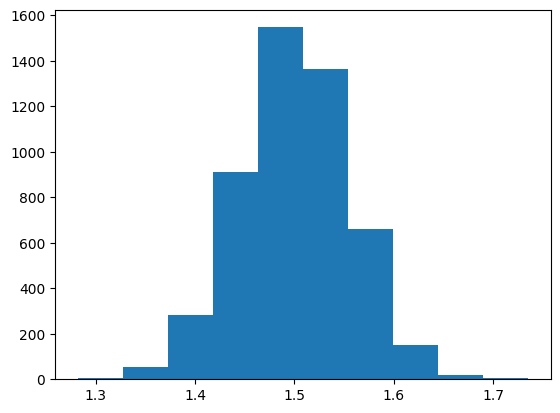

In [ ]:
#modules already imported at beginning of notebook

rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5

# get three'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start= 0, stop= 10, num = 11))*3)
n = len(x)

#prepare for the LR fit
reg = linear_model.LinearRegression()
#Create a reg object

#initialize array to save estimates (we don't need beta0 but I'm keeping it!)
beta_array= np.zeros(shape= (5000, 2))
for i in range(5000):
    #create the 'responses' modeled from the line plus a random deviation
    y = beta_0 + beta_1*x + rng.standard_normal(n)
    #find the least squares solutions and store them
    fit = reg.fit(x.reshape(-1, 1), y)
    beta_array[i, :] = [fit.intercept_, fit.coef_[0]]

#visualize the distribution of the slopedata
plt.hist(beta_array[:, 1])
plt.show()

In [ ]:
#estimate the probability we are larger than 1.65
bool_prob = beta_array[:, 1] > 1.65
bool_prob.mean()

np.float64(0.0038)

Please see the `.py` file attached in Moodle for Question 5. The code blocks below do some testing of what was created in the `.py` file.

In [3]:
#import some modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
from sklearn import linear_model


#defines the class
class SLR_slope_simulator:

    #creates initial attributes per instructions
    def __init__(self, beta_0, beta_1, x, sigma, seed):
        self.beta_0 = beta_0
        self.beta_1 = beta_1
        self.x = np.array(x)
        self.sigma = sigma
        self.rng = default_rng(seed)
        self.n = len(x)
        self.slopes = []


    def generate_data(self):
        #creates y values according to SLR formula
        y = self.beta_0 + (self.beta_1 * self.x) + self.rng.normal(0, self.sigma, self.n)

        #returns x and y as numpy arrays
        return self.x, np.array(y)

    def fit_slope(self, x, y):
        #creates a reg object
        reg = linear_model.LinearRegression()

        #fits the model
        mod_fit = reg.fit(x.reshape(-1, 1), y)

        #returns the estimated slope value
        return mod_fit.coef_[0]

    def run_simulations(self, sim_num):
        # initialize a numpy array of sim_num zeros (faster than using an empty list!)
        self.slopes = np.zeros(sim_num)

        #uses a for loop to generate data and fit the slopes for the number of simulations supplied
        for i in range(sim_num):
            x, y = self.generate_data() #supplies x & y arguments together for simulation i
            b1 = self.fit_slope(x, y) #returns slope value for simulation i
            self.slopes[i] = b1 #stores slope value in numpy array for simulation i

    def plot_sampling_distribution(self):
        if len(self.slopes) > 0: #plots sampling distribution of slopes if there are slopes to plot
            plt.hist(self.slopes)
            plt.title("Visualizing the Approximation to the Sampling \n Distribution of the Sample Slope")
            plt.xlabel("Estimated Slope Value")
            plt.ylabel("Frequency")
            plt.show() #eliminates printed text output that is not needed
        else: #prints message if user tries to plot before running simulations
            print("run_simulations() must be called first, please try again")

    def find_prob(self, value, sided):
        if len(self.slopes) > 0: #must have at least 1 slope to compute probability
            if sided == "above":
                bool_prob = self.slopes > value #formula for "above" probability
                return bool_prob.mean()
            elif sided == "below":
                bool_prob = self.slopes < value #formula for "below" probability
                return bool_prob.mean()
            elif sided == "two-sided":
                median_value = np.median(self.slopes) #computes median value of simulated slopes
                if value > median_value:
                    bool_prob = self.slopes >= value #formula for "two-sided" probability
                    return bool_prob.mean() * 2 #have to multiply by 2 since it's two-sided
                else:
                    bool_prob = self.slopes <= value #formula for "two-sided" probability
                    return bool_prob.mean() * 2 #have to multiply by 2 since it's two-sided
            else:
                raise ValueError("'sided' argument must be 'above', 'below', or 'two-sided'. Please try again.")
        else:
             print("run_simulations() must be called first, please try again")

In [4]:
test = SLR_slope_simulator(beta_0 = 12, beta_1 = 2, x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3),
                           sigma = 1, seed = 10) #creates instance of class object with given parameters

In [5]:
test.plot_sampling_distribution() #will return error message since we haven't yet run "run_simulations()"

run_simulations() must be called first, please try again


In [6]:
test.run_simulations(10000) #runs 10000 simulations

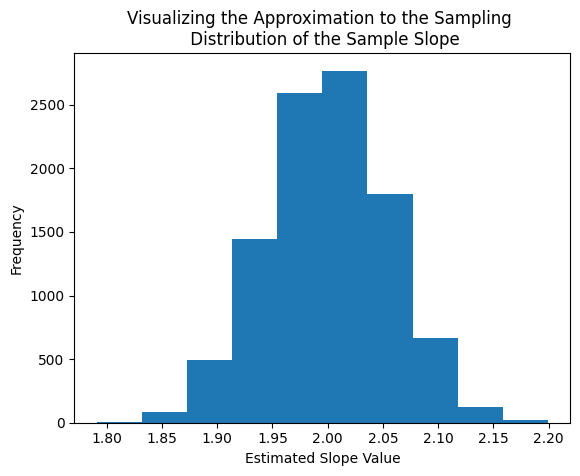

In [7]:
test.plot_sampling_distribution() #plots the sampling distribution

In [8]:
test.find_prob(2.1, "two-sided") #approximates the two-sided probability of being larger than 2.1

np.float64(0.0704)

In [9]:
test.slopes #prints out the values of the simulated slopes using the "slopes" attribute

array([2.0239168 , 1.99560551, 2.04249093, ..., 1.93451109, 2.01445559,
       2.07173587])